<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-weight:bold;font-family:Georgia,serif'>Décomposer un total — Météo</div></th></tr></table>
<table><tr><th><div style='padding:15px;color:#e50000;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>De quoi le total est-il composé ?</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_5.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_5_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 05 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Lecture de l’année 2024 uniquement, modifiable par ANNEE. Aucun dictionnaire d’unités n’est fourni : les valeurs sont compatibles avec °C, %, m/s et hPa, mais les axes conservent « unité source ». Les plages de contrôle sont des hypothèses exploratoires explicites, à valider avec le producteur. Les hors-plage sont masquées par variable et comptées, sans supprimer toute la ligne. Une moyenne entre stations n’est pas une moyenne climatique territoriale.

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Secteurs ou anneau
2. Barres empilées
3. Barres empilées à 100 %
4. Aires empilées
5. Treemap
6. Sunburst

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '05_meteo'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

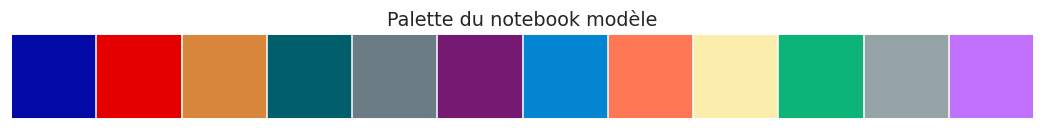

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>Station</td><td>Identifiant de station conservé en texte</td></tr><tr><td>DateHeure</td><td>Date de mesure sans fuseau documenté</td></tr><tr><td>Temperature / Humidite</td><td>Température et humidité dans les unités du fichier</td></tr><tr><td>VitesseVent / Pression</td><td>Mesures dans les unités du fichier</td></tr><tr><td>regime</td><td>Classe dérivée : température <10, de 10 à <20, ou ≥20</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['meteo']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
ANNEE = 2024
colonnes = ['Station', 'DateHeure', 'Temperature', 'Humidite', 'VitesseVent', 'Pression']
brut = pd.read_parquet(CHEMINS['meteo'],
                       filters=[('Annee', '==', ANNEE)]).drop(columns='Station').rename(columns={'Nom':'Station'})[colonnes]

donnees = brut.copy()
donnees['DateHeure'] = pd.to_datetime(donnees['DateHeure'], errors='coerce')
donnees = donnees.dropna(subset=['Station', 'DateHeure'])
print('Lignes source sur l’année :', len(brut), '; dates/stations absentes :', len(brut)-len(donnees))
print('Doublons station/date conservés et signalés :', donnees.duplicated(['Station','DateHeure']).sum())
# Pas de suppression automatique des doublons : plusieurs mesures peuvent être légitimes.
regles = {'Temperature': (-90, 60), 'Humidite': (0, 100), 'VitesseVent': (0, 150), 'Pression': (500, 1100)}
audit = []
for col, (bas, haut) in regles.items():
    donnees[col] = pd.to_numeric(donnees[col], errors='coerce')
    hors = donnees[col].notna() & ~donnees[col].between(bas, haut)
    audit.append([col, int(donnees[col].isna().sum()), int(hors.sum())])
    donnees.loc[hors, col] = np.nan
display(pd.DataFrame(audit, columns=['Variable','Absentes','Hors plage masquées']))
donnees['mois'] = donnees['DateHeure'].dt.month
donnees['jour'] = donnees['DateHeure'].dt.floor('D')
# Classes pédagogiques dans l’unité de température du fichier.
donnees['regime'] = pd.cut(donnees['Temperature'], [-np.inf,10,20,np.inf],
                           labels=['< 10', '10 à < 20', '≥ 20'], right=False)
stations = donnees.groupby('Station')['Temperature'].count().nlargest(6).index.tolist()
assert len(stations) >= 3
station = stations[0]
print('Année :', ANNEE, '; station principale :', station, '; stations retenues :', stations)
display(donnees.select_dtypes('number').describe().T)

Lignes source sur l’année : 122295 ; dates/stations absentes : 0
Doublons station/date conservés et signalés : 0


,Variable,Absentes,Hors plage masquées
0,Temperature,3042,0
1,Humidite,3346,0
2,VitesseVent,143,0
3,Pression,3432,0


Année : 2024 ; station principale : Alencon ; stations retenues : ['Alencon', 'Bale', 'Le Puy', 'Lille', 'Lyon', 'Nancy']


,count,mean,std,min,25%,50%,75%,max
Temperature,119253.0,13.311918,6.834883,-12.1,8.8,13.0,17.7,38.7
Humidite,118949.0,78.363618,16.311435,1.0,68.0,82.0,92.0,100.0
VitesseVent,122152.0,3.754066,2.591127,0.0,1.9,3.1,5.0,27.0
Pression,118863.0,995.395800,25.643462,888.5,985.9,1002.7,1012.2,1037.7
mois,122295.0,6.515181,3.452406,1.0,4.0,7.0,10.0,12.0


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Secteurs et anneau</div></b>

Décomposer les observations valides des six stations retenues selon les trois classes de température. Variables : régime C + effectif Q. Ce sont des parts de relevés, pas des parts de temps ou de territoire.

In [5]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

a=piv.sum().rename_axis('regime').reset_index(name='n')

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

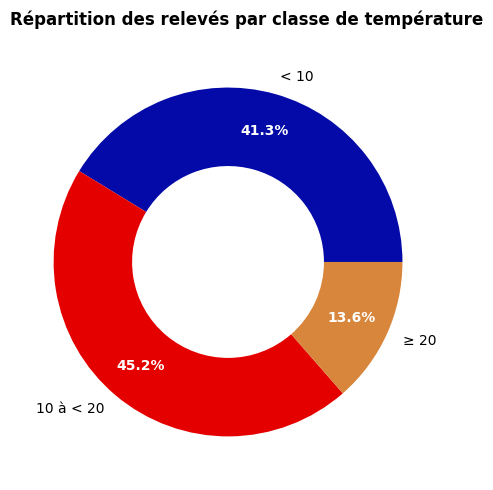

In [6]:
ID_GRAPHIQUE = '05_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.pie(a.n,labels=a.regime,autopct='%1.1f%%',pctdistance=.78,colors=palette[:3],wedgeprops={'width':.45});ax.set_aspect('equal')
for texte in ax.texts:
    if '%' in texte.get_text():texte.set_color('white');texte.set_fontweight('bold')
terminer(ax,'Répartition des relevés par classe de température')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

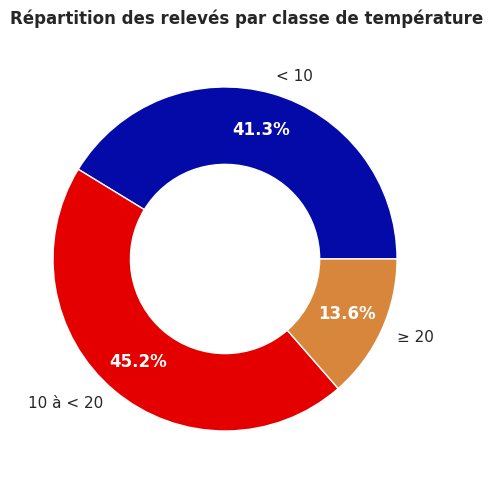

In [7]:
ID_GRAPHIQUE = '05_01'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.pie(a.n,labels=a.regime,autopct='%1.1f%%',pctdistance=.78,colors=sns.color_palette(palette[:3]),wedgeprops={'width':.45});ax.set_aspect('equal')
for texte in ax.texts:
    if '%' in texte.get_text():texte.set_color('white');texte.set_fontweight('bold')
terminer(ax,'Répartition des relevés par classe de température')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [8]:
ID_GRAPHIQUE = '05_01'
BIBLIOTHEQUE = 'plotly'
fig=px.pie(a,names='regime',values='n',hole=.55,color='regime',color_discrete_map=dict(zip(regimes,palette[:3])))
montrer_plotly(fig,'Répartition des relevés par classe de température')

**À lire dans les trois variantes :** Décomposer les observations valides des six stations retenues selon les trois classes de température. Variables : régime C + effectif Q. Ce sont des parts de relevés, pas des parts de temps ou de territoire.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Barres empilées</div></b>

Comparer volume de relevés et composition entre six stations. Variables : station C + régime C + effectif Q. Les volumes reflètent aussi la couverture des stations.

In [9]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

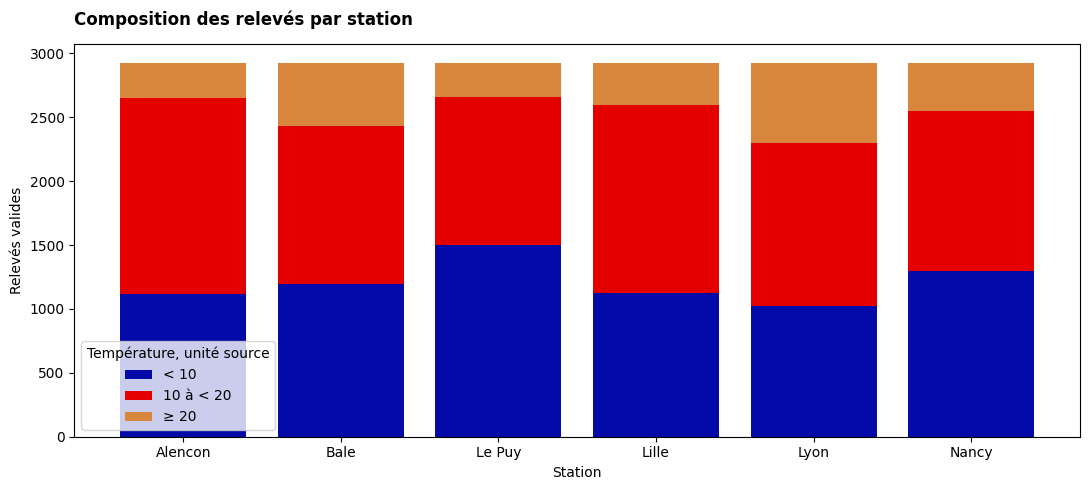

In [10]:
ID_GRAPHIQUE = '05_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
bas=np.zeros(len(piv))
for j,col in enumerate(piv):ax.bar(piv.index,piv[col],bottom=bas,label=col,color=palette[j]);bas+=piv[col].to_numpy()
ax.legend(title='Température, unité source')
terminer(ax,'Composition des relevés par station','Station','Relevés valides')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

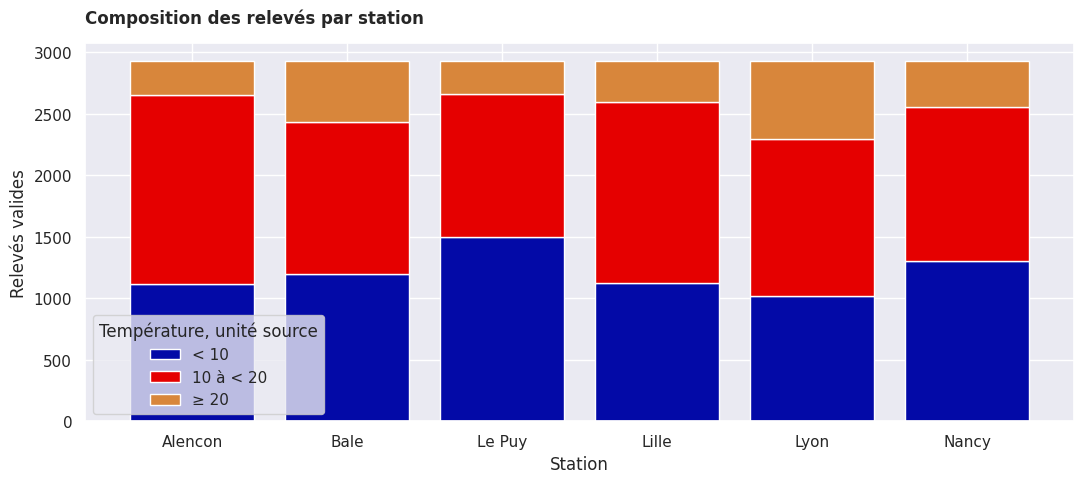

In [11]:
ID_GRAPHIQUE = '05_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
# Seaborn ne possède pas de barres empilées natives.
bas=np.zeros(len(piv))
for j,col in enumerate(piv):ax.bar(piv.index,piv[col],bottom=bas,label=col,color=sns.color_palette(palette)[j]);bas+=piv[col].to_numpy()
ax.legend(title='Température, unité source')
terminer(ax,'Composition des relevés par station','Station','Relevés valides')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [12]:
ID_GRAPHIQUE = '05_02'
BIBLIOTHEQUE = 'plotly'
a=piv.rename_axis('Station').reset_index().melt(id_vars='Station',var_name='regime',value_name='n')
fig=px.bar(a,x='Station',y='n',color='regime',barmode='stack',category_orders={'Station':stations,'regime':regimes},labels={'n':'Relevés valides'})
montrer_plotly(fig,'Composition des relevés par station')

**À lire dans les trois variantes :** Comparer volume de relevés et composition entre six stations. Variables : station C + régime C + effectif Q. Les volumes reflètent aussi la couverture des stations.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Barres empilées à 100 pour cent</div></b>

Comparer les proportions par station en neutralisant le nombre de relevés. Variables : station C + régime C + proportion Q. Les totaux sont disponibles dans la table ; les valeurs manquantes ne sont pas une quatrième classe.

In [13]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

parts=piv.div(piv.sum(axis=1),axis=0)*100
assert np.allclose(parts.sum(axis=1),100)
display(parts.round(1))

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,38.0,52.5,9.4
Bale,40.9,42.1,16.9
Le Puy,51.1,39.6,9.3
Lille,38.3,50.4,11.3
Lyon,34.8,43.6,21.5
Nancy,44.3,42.7,12.9


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

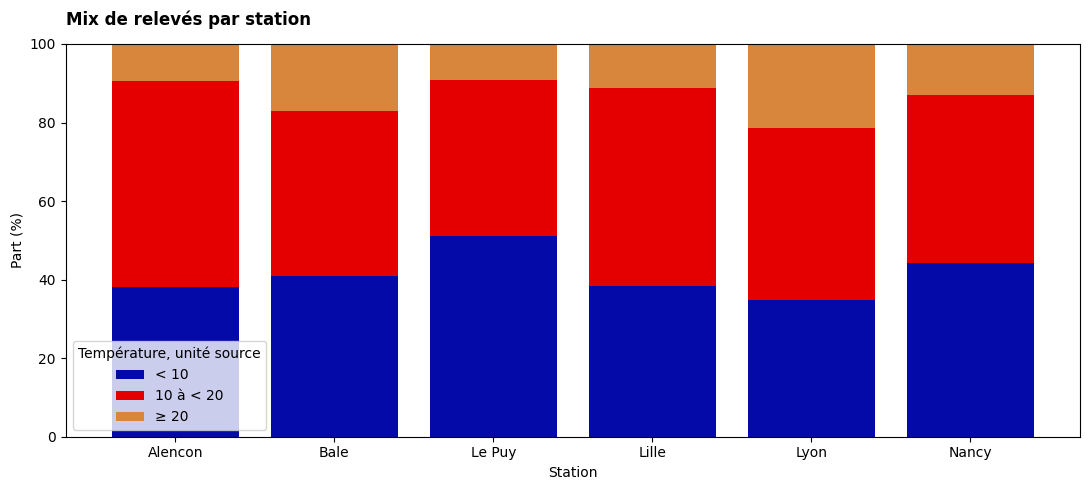

In [14]:
ID_GRAPHIQUE = '05_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
bas=np.zeros(len(parts))
for j,col in enumerate(parts):ax.bar(parts.index,parts[col],bottom=bas,label=col,color=palette[j]);bas+=parts[col].to_numpy()
ax.set_ylim(0,100);ax.legend(title='Température, unité source')
terminer(ax,'Mix de relevés par station','Station','Part (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

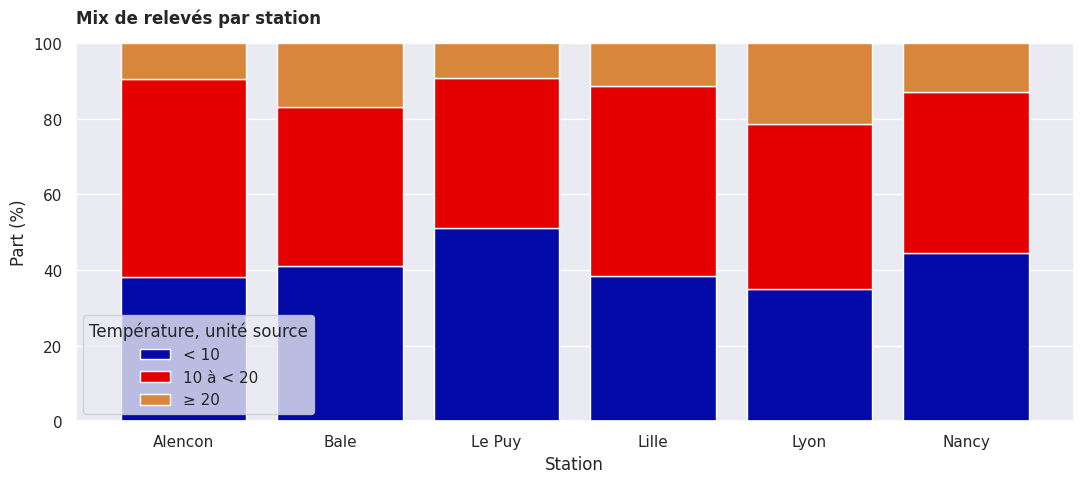

In [15]:
ID_GRAPHIQUE = '05_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
bas=np.zeros(len(parts))
for j,col in enumerate(parts):ax.bar(parts.index,parts[col],bottom=bas,label=col,color=sns.color_palette(palette)[j]);bas+=parts[col].to_numpy()
ax.set_ylim(0,100);ax.legend(title='Température, unité source')
terminer(ax,'Mix de relevés par station','Station','Part (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [16]:
ID_GRAPHIQUE = '05_03'
BIBLIOTHEQUE = 'plotly'
a=parts.rename_axis('Station').reset_index().melt(id_vars='Station',var_name='regime',value_name='part')
fig=px.bar(a,x='Station',y='part',color='regime',barmode='stack',category_orders={'Station':stations,'regime':regimes},labels={'part':'Part (%)'})
fig.update_yaxes(range=[0,100]);montrer_plotly(fig,'Mix de relevés par station')

**À lire dans les trois variantes :** Comparer les proportions par station en neutralisant le nombre de relevés. Variables : station C + régime C + proportion Q. Les totaux sont disponibles dans la table ; les valeurs manquantes ne sont pas une quatrième classe.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Aires empilées</div></b>

Suivre le nombre mensuel de relevés par classe de température sur les six stations retenues. Variables : mois T + régime C + effectif Q. Les mois ont des durées différentes et la couverture peut varier.

In [17]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

a=pd.crosstab(d.mois,d.regime).reindex(index=range(1,13),columns=regimes,fill_value=0)
display(a)

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


regime,< 10,10 à < 20,≥ 20
mois,,,
1,1284,204,0
2,1024,362,0
3,950,528,10
4,713,633,94
5,200,1154,134
6,72,968,400
7,10,789,689
8,19,654,815
9,192,1057,191


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

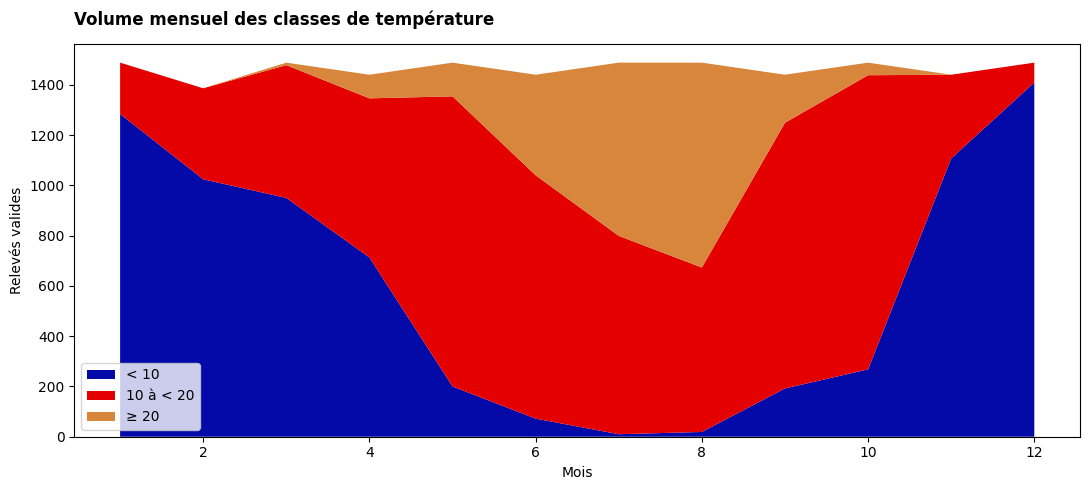

In [18]:
ID_GRAPHIQUE = '05_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.stackplot(a.index,a.to_numpy().T,labels=regimes,colors=palette[:3]);ax.legend();ax.set_ylim(bottom=0)
terminer(ax,'Volume mensuel des classes de température','Mois','Relevés valides')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

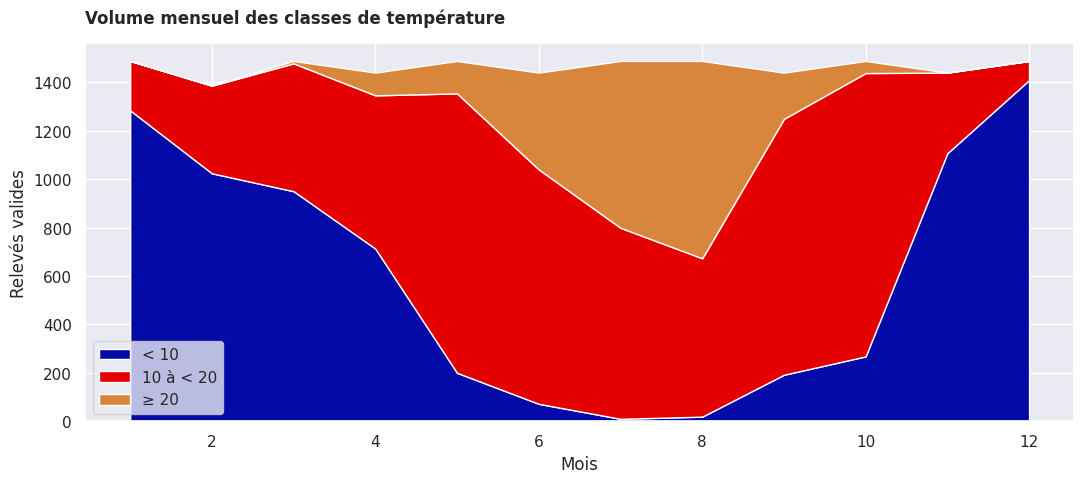

In [19]:
ID_GRAPHIQUE = '05_04'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.stackplot(a.index,a.to_numpy().T,labels=regimes,colors=sns.color_palette(palette[:3]));ax.legend();ax.set_ylim(bottom=0)
terminer(ax,'Volume mensuel des classes de température','Mois','Relevés valides')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [20]:
ID_GRAPHIQUE = '05_04'
BIBLIOTHEQUE = 'plotly'
long=a.rename_axis('mois').reset_index().melt(id_vars='mois',var_name='regime',value_name='n')
fig=px.area(long,x='mois',y='n',color='regime',category_orders={'regime':regimes},labels={'mois':'Mois','n':'Relevés valides'})
montrer_plotly(fig,'Volume mensuel des classes de température')

**À lire dans les trois variantes :** Suivre le nombre mensuel de relevés par classe de température sur les six stations retenues. Variables : mois T + régime C + effectif Q. Les mois ont des durées différentes et la couverture peut varier.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Treemap hiérarchique</div></b>

Décomposer les effectifs par station puis par classe. Structure : station > régime + effectif Q. L’aire totale reste proportionnelle au nombre de relevés ; le contour noir délimite une station.

In [21]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

rects=[]
parents=squarify.squarify(squarify.normalize_sizes(piv.sum(axis=1),100,100),0,0,100,100)
for station_nom,parent in zip(piv.index,parents):
    valeurs=piv.loc[station_nom];valeurs=valeurs[valeurs.gt(0)]
    enfants=squarify.squarify(squarify.normalize_sizes(valeurs,parent['dx'],parent['dy']),parent['x'],parent['y'],parent['dx'],parent['dy'])
    for regime,r in zip(valeurs.index,enfants):rects.append(dict(**r,station=station_nom,regime=regime,n=int(valeurs[regime])))

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

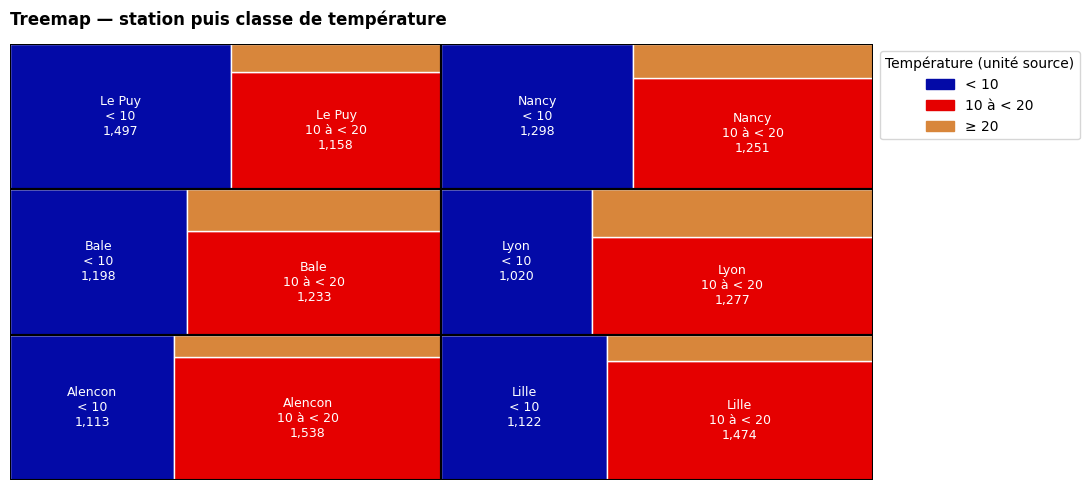

In [22]:
ID_GRAPHIQUE = '05_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes(False)
for r in rects:
    ax.add_patch(Rectangle((r['x'],r['y']),r['dx'],r['dy'],facecolor=palette[regimes.index(r['regime'])],edgecolor='white'))
    if r['dy']>=12 and r['dx']>=10:ax.text(r['x']+r['dx']/2,r['y']+r['dy']/2,f"{r['station']}\n{r['regime']}\n{r['n']:,}",ha='center',va='center',fontsize=9,color='white')
for r in parents:ax.add_patch(Rectangle((r['x'],r['y']),r['dx'],r['dy'],fill=False,edgecolor='black',linewidth=1.5))
ax.set(xlim=(0,100),ylim=(0,100));ax.axis('off')
ax.legend([Rectangle((0,0),1,1,color=palette[j]) for j in range(3)],regimes,title='Température (unité source)',loc='upper left',bbox_to_anchor=(1,1))
terminer(ax,'Treemap — station puis classe de température')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

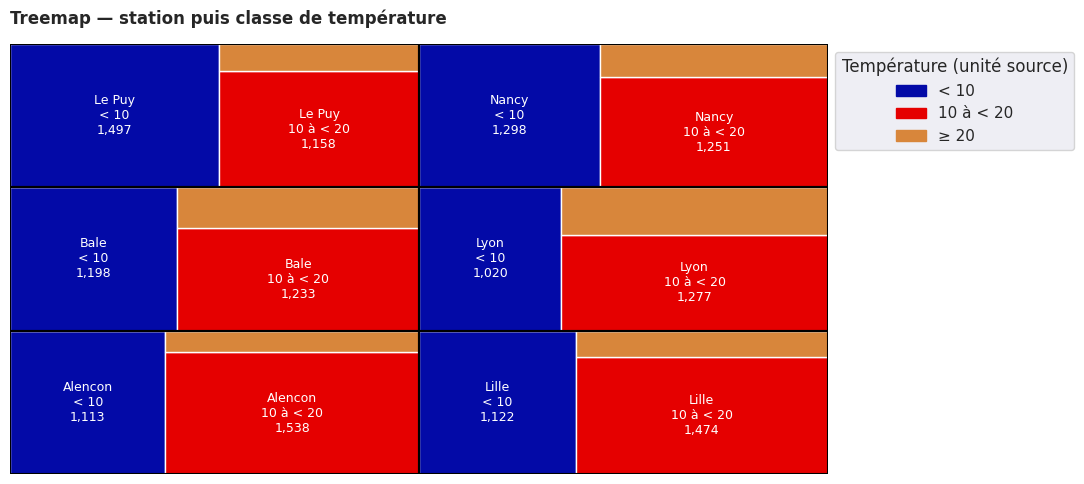

In [23]:
ID_GRAPHIQUE = '05_05'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
for r in rects:
    ax.add_patch(Rectangle((r['x'],r['y']),r['dx'],r['dy'],facecolor=palette[regimes.index(r['regime'])],edgecolor='white'))
    if r['dy']>=12 and r['dx']>=10:ax.text(r['x']+r['dx']/2,r['y']+r['dy']/2,f"{r['station']}\n{r['regime']}\n{r['n']:,}",ha='center',va='center',fontsize=9,color='white')
for r in parents:ax.add_patch(Rectangle((r['x'],r['y']),r['dx'],r['dy'],fill=False,edgecolor='black',linewidth=1.5))
ax.set(xlim=(0,100),ylim=(0,100));ax.axis('off')
ax.legend([Rectangle((0,0),1,1,color=palette[j]) for j in range(3)],regimes,title='Température (unité source)',loc='upper left',bbox_to_anchor=(1,1))
terminer(ax,'Treemap — station puis classe de température')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [24]:
ID_GRAPHIQUE = '05_05'
BIBLIOTHEQUE = 'plotly'
long=piv.rename_axis('Station').reset_index().melt(id_vars='Station',var_name='regime',value_name='n');long=long.loc[long.n.gt(0)]
fig=px.treemap(long,path=['Station','regime'],values='n',color='regime',color_discrete_map=dict(zip(regimes,palette[:3])))
montrer_plotly(fig,'Treemap — station puis classe de température')

**À lire dans les trois variantes :** Décomposer les effectifs par station puis par classe. Structure : station > régime + effectif Q. L’aire totale reste proportionnelle au nombre de relevés ; le contour noir délimite une station.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Sunburst</div></b>

Lire les mêmes effectifs dans une hiérarchie radiale. Structure : station > régime + effectif Q. Les petits secteurs se comparent moins précisément qu’avec des barres.

In [25]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

secteurs=[];debut=0.;total=float(piv.to_numpy().sum())
for nom,r in piv.iterrows():
    angle=360*r.sum()/total
    secteurs.append((debut,debut+angle,0.55,0.28,nom,0))
    sous=debut
    for j,regime in enumerate(regimes):
        delta=360*r[regime]/total
        if delta>0:secteurs.append((sous,sous+delta,1.,.42,regime,j))
        sous+=delta
    debut+=angle

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

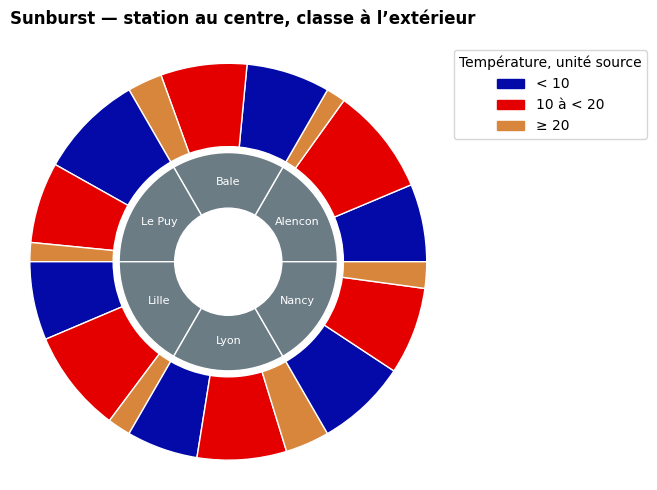

In [26]:
ID_GRAPHIQUE = '05_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes(False)
for a0,a1,r,w,label,j in secteurs:
    ax.add_patch(Wedge((0,0),r,a0,a1,width=w,facecolor=palette[j] if r==1 else '#6b7c85',edgecolor='white'))
    if r<1:
        ang=np.deg2rad((a0+a1)/2);ax.text(.4*np.cos(ang),.4*np.sin(ang),label,ha='center',va='center',fontsize=8,color='white')
handles=[Rectangle((0,0),1,1,color=palette[j]) for j in range(3)];ax.legend(handles,regimes,title='Température, unité source',loc='upper left',bbox_to_anchor=(1,1))
ax.set(xlim=(-1.1,1.1),ylim=(-1.1,1.1),aspect='equal');ax.axis('off')
terminer(ax,'Sunburst — station au centre, classe à l’extérieur')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

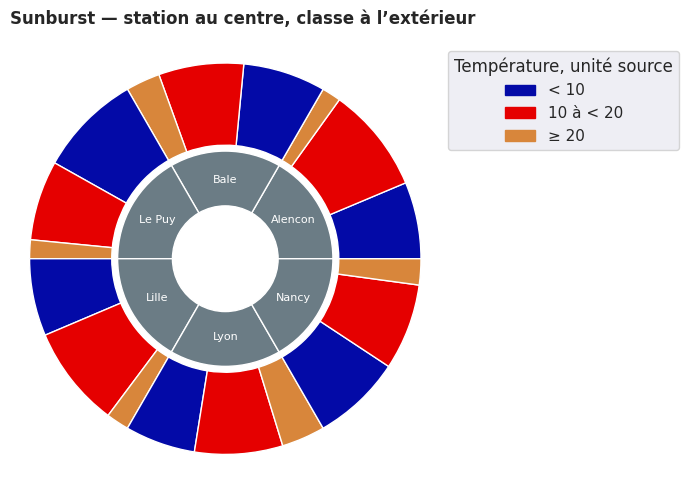

In [27]:
ID_GRAPHIQUE = '05_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
for a0,a1,r,w,label,j in secteurs:
    ax.add_patch(Wedge((0,0),r,a0,a1,width=w,facecolor=palette[j] if r==1 else '#6b7c85',edgecolor='white'))
    if r<1:
        ang=np.deg2rad((a0+a1)/2);ax.text(.4*np.cos(ang),.4*np.sin(ang),label,ha='center',va='center',fontsize=8,color='white')
handles=[Rectangle((0,0),1,1,color=palette[j]) for j in range(3)];ax.legend(handles,regimes,title='Température, unité source',loc='upper left',bbox_to_anchor=(1,1))
ax.set(xlim=(-1.1,1.1),ylim=(-1.1,1.1),aspect='equal');ax.axis('off')
terminer(ax,'Sunburst — station au centre, classe à l’extérieur')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

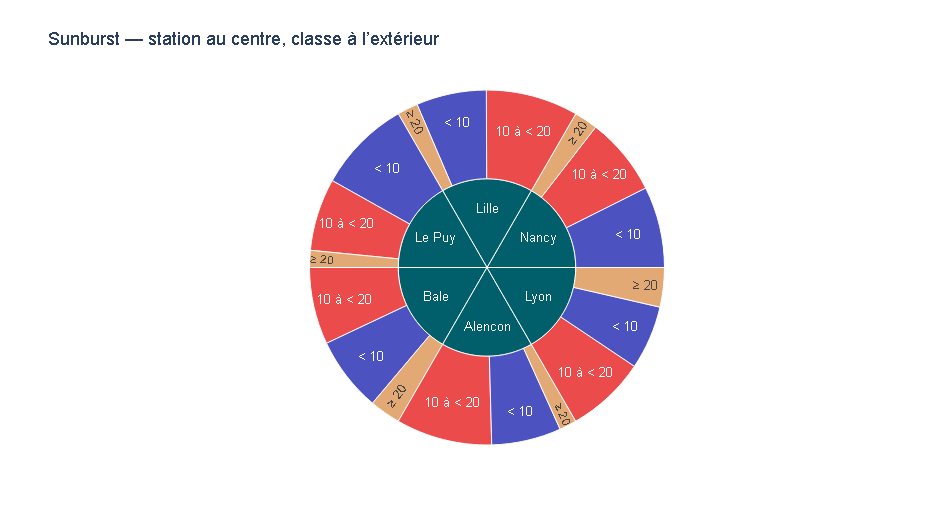

In [28]:
ID_GRAPHIQUE = '05_06'
BIBLIOTHEQUE = 'plotly'
long=piv.rename_axis('Station').reset_index().melt(id_vars='Station',var_name='regime',value_name='n');long=long.loc[long.n.gt(0)]
fig=px.sunburst(long,path=['Station','regime'],values='n',color='regime',color_discrete_map=dict(zip(regimes,palette[:3])))
montrer_plotly(fig,'Sunburst — station au centre, classe à l’extérieur')

**À lire dans les trois variantes :** Lire les mêmes effectifs dans une hiérarchie radiale. Structure : station > régime + effectif Q. Les petits secteurs se comparent moins précisément qu’avec des barres.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Lecture de l’année 2024 uniquement, modifiable par ANNEE. Aucun dictionnaire d’unités n’est fourni : les valeurs sont compatibles avec °C, %, m/s et hPa, mais les axes conservent « unité source ». Les plages de contrôle sont des hypothèses exploratoires explicites, à valider avec le producteur. Les hors-plage sont masquées par variable et comptées, sans supprimer toute la ligne. Une moyenne entre stations n’est pas une moyenne climatique territoriale.